# Deduplicating Text in Common-Crawl for LLM Training. 

<a target="_blank" href="https://colab.research.google.com/github/everettVT/daft-minhash-dedupe/blob/main/workload/minhash_dedupe_common_crawl.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In this notebook, we will cover how to perform the minhash deduplication algorithm on html documents from the common crawl dataset. By the end, we will walk through a practical approach to deduplicating text at scale.

The Common Crawl corpus contains petabytes of data, with its oldest entries dating back to 2008, including raw web page data, metadata extracts, and text extracts.

LLMs require massive amounts of data to train on. Early foundation models like GPT-3 and T5 saw improvements in model performance due to deduplication efforts. Deduplication makes it far less likely that the model regurgitates memorized text leading to better responses.

*See [Deduplicating Training Data Makes Language Models Better (Lee et. all)](https://aclanthology.org/2022.acl-long.577.pdf)*

---


## Table of Contents
- [Quickstart](#quickstart)
- [AWS Authentication](#aws-authentication)
- [Loading and Preprocessing](#loading-and-preprocessing)
- [Text Normalization](#text-normalization)
- [The MinHash Deduplication algorithm](#the-minhash-deduplication-algorithm)
- [LSH Banding](#lsh-banding)
- [Connected Components](#connected-components)
- [Validation with igraph](#validation-with-igraph)
- [Merge Results](#merge-results)
- [Conclusion](#conclusion)

## Quickstart

In [ ]:
# Install dependencies (skip if using uv - dependencies are already in pyproject.toml)
# For Google Colab or standalone environments:
!pip install 'daft[aws,pandas]' selectolax scipy matplotlib igraph

zsh:1: command not found: pip


## AWS Authentication

Crawl data is free to access by anyone from anywhere. The data is hosted by Amazon Web Services’ Open Data Sets Sponsorships program on the bucket s3://commoncrawl/, located in the US-East-1 (Northern Virginia) AWS Region. The most performative means of accessing Common crawl is through s3, so you'll need to authenticate with a `AWS_ACCESS_KEY_ID` and `AWS_SECRET_ACCESS_KEY`. 

Common Crawl data can also be accessed without authentication, anonymously via it's http endpoint, but for the purposes of this walkthrough we are going to stick with S3. 


In [ ]:
import daft
from daft.io import IOConfig, S3Config
import os
from dotenv import load_dotenv
from IPython.display import clear_output

# Make sure to define your AWS_ACCESS_KEY_ID and AWS_SECRET_ACCESS_KEY in your environment variables or in a .env file
load_dotenv()  # Or !export AWS_ACCESS_KEY_ID=xxx && export AWS_SECRET_ACCESS_KEY=yyy

s3_config = S3Config(
    region_name="us-east-1",
    requester_pays=True,
    key_id=os.environ["AWS_ACCESS_KEY_ID"],
    access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    anonymous=False,
)

IO_CONFIG = IOConfig(s3=s3_config)
daft.set_planning_config(default_io_config=IO_CONFIG)

DaftContext(_ctx=<builtins.PyDaftContext object at 0x13675e030>)

---

# Defining Key Parameters

In [ ]:
NUM_ROWS = 500 # We'll limit this demo to a small number of rows for our initial walkthrough
index_col = "block_id" 
content_col = "block"
common_crawl_segment = "CC-MAIN-2018-17"
uri = f"s3://commoncrawl/crawl-data/{common_crawl_segment}/segments/*/warc/*.warc.gz"

# Minhash Parameters
K = 64 # Number of Permutations
SEED = 42 # Seed for the hash function 
NGRAM_SIZE = 5 # Size of the n-grams
LSH_THRESHOLD = 0.7 # Jaccard Similarity Threshold for LSH

## Loading & Preprocessing Common Crawl Documents 

We will be accessing Common Crawl through [WARC files](https://commoncrawl.org/blog/navigating-the-warc-file-format) since daft supports the format natively with `daft.read_warc(uri)`

In [ ]:
# Let's investigate the different types of payloads we have: 
df_warc = daft.read_warc(uri).limit(NUM_ROWS).collect() # Materialize to avoid re-reading from s3

/Users/everett-founder/git/ugh/daft-minhash-dedupe/.venv/lib/python3.11/site-packages/daft/dashboard/__init__.py:91: UserWarning: Failed to broadcast metrics over http://127.0.0.1:3238/api/queries: HTTP Error 400: Bad Request
  warnings.warn(f"Failed to broadcast metrics over {url}: {e}")


🗡️ 🐟 Warc Scan: 00:00 

🗡️ 🐟 Limit 500: 00:00 

In [113]:
# Lets investigate the different types of payloads we have: 
df_warc.select("WARC-Identified-Payload-Type").distinct().show()

WARC-Identified-Payload-TypeUtf8
application/xhtml+xml
text/html
application/pdf
application/zip
None


### Preprocessing
Since we are primarily concerned with text, we will focus on `text/html` payloads, extracting text content from html body and normalizing the text itself. 


In [ ]:
from daft import col
from daft.functions import monotonically_increasing_id

# Define a UDF to remove http headers from the payload
@daft.func()
def remove_http_headers(x: str) -> str:
    """Remove HTTP headers from input string by splitting on double CRLF, returning the body or empty string."""
    if x is None:
        return ""
    if len(x.split("\r\n\r\n")) > 1:
        return x.split("\r\n\r\n")[1]
    return ""

# Filter the dataframe to only include text/html payloads
df_html = df_warc.where(col("WARC-Identified-Payload-Type")== "text/html")

# Create a Daft Expression to decode WARC content from bytes to UTF-8 and strip HTTP headers
# Learn more about Daft Expressions: https://docs.daft.ai/en/stable/api/expressions/
warc_without_headers_expr = remove_http_headers(col("warc_content").try_decode("utf-8"))

# Separate the http headers from the payloads and filter out empty content
df_html = (
    df_html
    .with_column("content_raw", warc_without_headers_expr)
    .where(col("content_raw") != "")
)

#### Extracting Text from HTML

In [115]:
from selectolax.parser import HTMLParser
import re

# Define a UDF to extract text from HTML content, Specifically (article, main, p, h1, h2, h3, li)
@daft.func()
def extract_blocks(html: str) -> list[str]:
    tree = HTMLParser(html)
    for n in tree.css("script,style,noscript"):
        n.decompose()

    blocks = []
    for node in tree.css("""title, article, main, p, h1, h2, h3, h4, h5, h6, li, div, section, img[alt], figcaption, caption, blockquote, table th, table td, pre, code, summary, meta[name="description"], meta[property="og:title"], meta[property="og:description"]"""):
        txt = node.text(separator=" ", strip=True)
        if txt: 
            blocks.append(txt)
    return blocks

@daft.func()
def get_block_idx(blocks: list[str]) -> list[int]:
    return list(range(len(blocks)))

df_text = (
    df_html
    .with_column("blocks", extract_blocks(col("content_raw")))
    .with_column("block_idx", get_block_idx(col("blocks")))
    .explode("blocks", "block_idx")
    .where(col("blocks") != "")
    .where(col("blocks").not_null())
    .with_column(index_col, col("WARC-Record-ID")+ "-" + col("block_idx"))
    .with_column(content_col, col("blocks"))
    .select(
        "WARC-Record-ID",
        index_col,
        content_col,
    )
)
df_text = df_text.collect()
df_text.show(3)

WARC-Record-IDUtf8,block_idUtf8,blockUtf8
49d8d55d-9a84-42a2-8de1-fbbf84107042,49d8d55d-9a84-42a2-8de1-fbbf84107042-0,日本福利直播軟件app
49d8d55d-9a84-42a2-8de1-fbbf84107042,49d8d55d-9a84-42a2-8de1-fbbf84107042-1,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.
49d8d55d-9a84-42a2-8de1-fbbf84107042,49d8d55d-9a84-42a2-8de1-fbbf84107042-2,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.


#### Drop Unecessary columns 

In [116]:
# Drop Un-needed Columns
df_ready = (
    df_text
    .select(index_col, content_col)
)


### Text Normalization 

So far we have extracted the text out of each html document into blocks. Now we move to normalize the text blocks to prepare for the MinHash operation. 

*Note: It is recommended to run your preprocessing pipeline seperately from your minhash deduplication workload.* 

In [117]:
# Normalize text 
df_norm = df_ready.with_column("content_normalized", 
    col(content_col).str.normalize(
        remove_punct=True, 
        lowercase=True, 
        nfd_unicode=True, 
        white_space=True
    ) 
)
df_norm.select(index_col, content_col, "content_normalized").show(3)

block_idUtf8,blockUtf8,content_normalizedUtf8
49d8d55d-9a84-42a2-8de1-fbbf84107042-0,日本福利直播軟件app,日本福利直播軟件app
49d8d55d-9a84-42a2-8de1-fbbf84107042-1,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.,會員登入 加入會員 查詢密碼 客服qq 2094229240qqcom 免費文字聊天區 一對一視訊聊天 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 七微 我在休息 最近上線時間 20180422 042524 加到我的最愛 說明 詳細資料 免費文字聊天 必需付費才可聊天 血型 一對多視訊聊天 每分鐘 8 點 身高 公分cm 一對一視訊聊天 每分鐘 30 點 體重 公斤kg 性別 女性 三圍 年齡 19 歲 區域 苗栗縣市 會員總評價 相貌 平均評價 500 分 身材 平均評價 500 分 表演 平均評價 500 分 態度 平均評價 500 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員 lv4502611 yyyyybw 的評論： 超nice的girl，性格极好，音也好听，e杯 20180417 035827 相貌 身材 表演 態度 會員 lv2185509 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要 20180411 015511 相貌 身材 表演 態度 會員 lv3719146 dragon 的評論： 妹妹很投入，很配合，讓人很爽 20180404 042311 相貌 身材 表演 態度 會員 lv2438679 good 的評論： 超棒的妹妹配合度高很會秀 20180323 163255 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 20180422 0339 0425 46 分鐘 2 0109 0317 128 分鐘 3 0055 0105 10 分鐘 4 0000 0053 53 分鐘 5 20180421 2356 2359 3 分鐘 6 2339 2343 4 分鐘 7 2310 2329 19 分鐘 8 20180419 0207 0216 9 分鐘 9 0028 0146 78 分鐘 10 0000 0005 5 分鐘 11 20180418 2340 2359 19 分鐘 12 2220 2337 77 分鐘 13 2152 2218 26 分鐘 14 0327 0338 11 分鐘 15 0119 0324 125 分鐘 16 0040 0100 20 分鐘 17 0011 0022 11 分鐘 18 20180417 2340 2352 12 分鐘 19 2315 2330 15 分鐘 20 2310 2313 3 分鐘 21 1327 1345 19 分鐘 22 1249 1324 35 分鐘 23 1215 1240 24 分鐘 24 0232 0421 109 分鐘 25 0045 0208 84 分鐘 26 0000 0037 38 分鐘 27 20180416 2319 2359 40 分鐘 28 2112 2257 105 分鐘 29 1544 1616 32 分鐘 30 1210 1436 146 分鐘 主持人個人首頁 評價 記錄 copyrightc2006 1765634yyappyycom all rights reserved
49d8d55d-9a84-42a2-8de1-fbbf84107042-2,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘

### The MinHash Deduplication algorithm

If you google "minhash deduplication" you'll find a variety of sources that can walk you through the aglorithm. [Finding Near Duplicates with Jaccard Similarity and MinHash by Nelson Elhage](https://blog.nelhage.com/post/fuzzy-dedup/) is a great place to start, but if you are looking for the canonical reference for the MinHash deduplication algorithm, it originates from the seminal paper by Andrei Z. Broder, published in 1997, titled:

```text
"On the resemblance and containment of documents"
Published in: Proceedings of the Compression and Complexity of Sequences 1997 (SEQUENCES '97)
Publisher: IEEE Computer Society
DOI: 10.1109/SEQUEN.1997.666900
```

A video walkthough of the algorithm is also available through [Mike Mull's presentation on YouTube](https://www.youtube.com/watch?v=KKNPmvELUP4). He even provides a [jupyter notebook](https://github.com/papers-we-love/san-diego/blob/master/presentations/2016-11-03-resemblance-containment-documents/Broder97.ipynb) detailing the core primatives and how they are calculated in pure python. 

---

Luckily, daft has a built in minhash expression. That means building shingles and deciding on the hashing structure is done for us!

In [118]:
# Calculate the minhash vectors
df_minhash = (
    df_norm
    .with_column("min_hashes", col("content_normalized").minhash(
        num_hashes = K,
        ngram_size = NGRAM_SIZE,
        seed = SEED, 
        hash_function = 'xxhash'
        )
    )
)
df_minhash.select(index_col, content_col, "min_hashes").show(3)

block_idUtf8,blockUtf8,min_hashesFixedSizeList[UInt32; 64]
49d8d55d-9a84-42a2-8de1-fbbf84107042-0,日本福利直播軟件app,"[3386667336, 3670515532, 1992271906, 797969041, 1415772294, 4121350636, 2395907576, 1405787327, 3501771985, 3959548303, 580344897, 1945224165, 2236912579, 2331074647, 3876632889, 329032326, 855069210, 517883514, 889551018, 555385527, 4028037647, 3674237166, 1484594459, 2869405512, 3546425185, 513748255, 42994675, 2357306769, 3614962004, 2566715112, 3845190625, 2187652081, 1626367139, 2881074939, 2383474561, 2781261162, 2131592846, 1524973119, 2623557367, 451764430, 694706097, 1104394467, 3018668595, 4160732402, 2986966271, 282649113, 2473567297, 3830448270, 825388198, 2663173717, 1367759604, 1674369853, 2058055147, 2623099751, 3422042298, 3189089471, 260248479, 185456152, 1254966011, 3666870830, 1372722400, 2442887459, 4239564222, 3344000567]"
49d8d55d-9a84-42a2-8de1-fbbf84107042-1,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.,"[5667683, 16889265, 24612928, 29265701, 22586085, 20238988, 14678865, 28498456, 14894739, 6477459, 8544877, 34440093, 2105286, 18618595, 25444337, 17982572, 7430491, 8848102, 260410, 42502699, 3632984, 73591, 39792263, 12917782, 1257310, 8808877, 711845, 1214048, 20891513, 6541585, 5179596, 46675261, 3236987, 51199547, 7516842, 25620620, 4378418, 5864943, 11876663, 9529211, 3378115, 3985688, 12644188, 16948915, 34727709, 27655827, 27280070, 44496059, 786141, 5732695, 3653296, 12689694, 14259762, 19176355, 7563562, 12219639, 50931091, 16134597, 5890680, 4932158, 15901750, 5888162, 40054961, 9745750]"
49d8d55d-9a84-42a2-8de1-fbbf84107042-2,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18

## LSH Banding

Next, we will:
1. Use the optimal_param function to determine the best band (b) and row (r) parameters for our LSH bucketing
2. Split each document's minhash vector into `B` bands of `R` rows each
3. Create buckets by hashing each band's signature, grouping similar documents together


In [119]:
from scipy.integrate import quad as integrate

def optimal_param(
    threshold: float,
    num_perm: int,
    false_positive_weight: float = 0.5,
    false_negative_weight: float = 0.5,
):
    """
    Compute the optimal `MinHashLSH` parameter that minimizes the weighted sum
    of probabilities of false positive and false negative, taken from datasketch.

    Parameters
    ----------
    threshold : float
        The threshold for similarity.
    num_perm : int
        The number of permutations.
    false_positive_weight : float
        The weight of false positive.
    false_negative_weight : float
        The weight of false negative.

    Returns
    -------
    Tuple[int, int]
        The optimal `b` and `r` parameters.
        The number of bands, and the number of rows per band respectively.

    Examples
    --------
    >>> optimal_param(0.7, 256)
    (25, 10)
    """

    def false_positive_area(threshold: float, b: int, r: int):
        """Source: `datasketch.lsh`"""

        def area(s):
            return 1 - (1 - s ** float(r)) ** float(b)

        a, _ = integrate(area, 0.0, threshold)
        return a

    def false_negative_area(threshold: float, b: int, r: int):
        """Source: `datasketch.lsh`"""

        def area(s):
            return 1 - (1 - (1 - s ** float(r)) ** float(b))

        a, _ = integrate(area, threshold, 1.0)
        return a

    min_error = float("inf")
    opt = (0, 0)
    for b in range(1, num_perm + 1):
        max_r = int(num_perm / b)
        for r in range(1, max_r + 1):
            fp = false_positive_area(threshold, b, r)
            fn = false_negative_area(threshold, b, r)
            error = fp * false_positive_weight + fn * false_negative_weight
            if error < min_error:
                min_error = error
                opt = (b, r)
    return opt

Try tweaking the threshold value to see what happens

In [120]:
# Choose B bands and R rows per band such that B · R = num_perm.
B, R = optimal_param(0.7, K)
print(B, R, K)
# Verify that B * R = K
assert B * R == K 

8 8 64


Before we move to Band Generation, we need to hash our `index_col` to `int` to make downstream processing easier. 
We will keep track of the map and introduce a new column with a monotonically increasing id.  

In [121]:
df_minhash = df_minhash.with_column("node_id", monotonically_increasing_id())
id_map = df_minhash.select(index_col, "node_id").distinct()

### Band Generation

**Previously** we calculated the minhashes for our `content_text` where we hashed each word token into an 8 byte integer, taking only 32 samples (at a uniform random sample). 

**Next** we took those 32 hashes and chunked them into 4 lists of 8 values. 

In [122]:
# Band Generation
df_bands = (
    df_minhash
    .with_column("bands", col("min_hashes").list.chunk(R))
)
df_bands.select(index_col, content_col, "min_hashes", "bands").show(3)    

block_idUtf8,blockUtf8,min_hashesFixedSizeList[UInt32; 64],bandsList[FixedSizeList[UInt32; 8]]
49d8d55d-9a84-42a2-8de1-fbbf84107042-0,日本福利直播軟件app,"[3386667336, 3670515532, 1992271906, 797969041, 1415772294, 4121350636, 2395907576, 1405787327, 3501771985, 3959548303, 580344897, 1945224165, 2236912579, 2331074647, 3876632889, 329032326, 855069210, 517883514, 889551018, 555385527, 4028037647, 3674237166, 1484594459, 2869405512, 3546425185, 513748255, 42994675, 2357306769, 3614962004, 2566715112, 3845190625, 2187652081, 1626367139, 2881074939, 2383474561, 2781261162, 2131592846, 1524973119, 2623557367, 451764430, 694706097, 1104394467, 3018668595, 4160732402, 2986966271, 282649113, 2473567297, 3830448270, 825388198, 2663173717, 1367759604, 1674369853, 2058055147, 2623099751, 3422042298, 3189089471, 260248479, 185456152, 1254966011, 3666870830, 1372722400, 2442887459, 4239564222, 3344000567]","[[3386667336, 3670515532, 1992271906, 797969041, 1415772294, 4121350636, 2395907576, 1405787327], [3501771985, 3959548303, 580344897, 1945224165, 2236912579, 2331074647, 3876632889, 329032326], [855069210, 517883514, 889551018, 555385527, 4028037647, 3674237166, 1484594459, 2869405512], [3546425185, 513748255, 42994675, 2357306769, 3614962004, 2566715112, 3845190625, 2187652081], [1626367139, 2881074939, 2383474561, 2781261162, 2131592846, 1524973119, 2623557367, 451764430], [694706097, 1104394467, 3018668595, 4160732402, 2986966271, 282649113, 2473567297, 3830448270], [825388198, 2663173717, 1367759604, 1674369853, 2058055147, 2623099751, 3422042298, 3189089471], [260248479, 185456152, 1254966011, 3666870830, 1372722400, 2442887459, 4239564222, 3344000567]]"
49d8d55d-9a84-42a2-8de1-fbbf84107042-1,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.,"[5667683, 16889265, 24612928, 29265701, 22586085, 20238988, 14678865, 28498456, 14894739, 6477459, 8544877, 34440093, 2105286, 18618595, 25444337, 17982572, 7430491, 8848102, 260410, 42502699, 3632984, 73591, 39792263, 12917782, 1257310, 8808877, 711845, 1214048, 20891513, 6541585, 5179596, 46675261, 3236987, 51199547, 7516842, 25620620, 4378418, 5864943, 11876663, 9529211, 3378115, 3985688, 12644188, 16948915, 34727709, 27655827, 27280070, 44496059, 786141, 5732695, 3653296, 12689694, 14259762, 19176355, 7563562, 12219639, 50931091, 16134597, 5890680, 4932158, 15901750, 5888162, 40054961, 9745750]","[[5667683, 16889265, 24612928, 29265701, 22586085, 20238988, 14678865, 28498456], [14894739, 6477459, 8544877, 34440093, 2105286, 18618595, 25444337, 17982572], [7430491, 8848102, 260410, 42502699

**Now** we will explode our bands into new rows, keeping track of their position in the band using `band_idx`. 

In [123]:
@daft.func()
def get_band_idx(band: list[int], B: int) -> list[int]:
    return list(range(min(len(band), B)))

df_bands_exploded = (
    df_bands
    .with_column("band_idx", get_band_idx(col("bands"), B)) 
    .explode("bands", "band_idx")
)
df_bands_exploded.select("node_id", "band_idx", "bands").show(3)

🗡️ 🐟 UDF get_band_idx: 00:00 

node_idUInt64,band_idxInt64,bandsFixedSizeList[UInt32; 8]
0,0,"[3386667336, 3670515532, 1992271906, 797969041, 1415772294, 4121350636, 2395907576, 1405787327]"
0,1,"[3501771985, 3959548303, 580344897, 1945224165, 2236912579, 2331074647, 3876632889, 329032326]"
0,2,"[855069210, 517883514, 889551018, 555385527, 4028037647, 3674237166, 1484594459, 2869405512]"


### Grouping bands 
We then group the bands against their 'signature', which is a combination of their band index and the band itself. If two segments are duplicates, we expect their signatures to match. 

In [124]:
# Grouping Bands
df_grouped = (
    df_bands_exploded
    .groupby(col("band_idx"), col("bands"))
    .agg(col("node_id").agg_list().alias("nodes"))
)
df_grouped.select("band_idx", "bands", "nodes").show(3)

band_idxInt64,bandsFixedSizeList[UInt32; 8],nodesList[UInt64]
2,"[4000912338, 2001651524, 160892922, 315158091, 494043173, 3391623666, 2194692531, 2096625388]",[3761]
4,"[13108892, 14617798, 15346869, 90307012, 754502, 1306594, 41851460, 30741526]",[5415]
4,"[842798334, 4215060598, 2395166450, 1874484820, 3842730105, 2329679939, 711028093, 1855515321]",[5619]


In [125]:
# Inspecting bands with multiple nodes
df_grouped.where(col("nodes").list.length() > 1).select("band_idx", "bands", "nodes").show(3)

band_idxInt64,bandsFixedSizeList[UInt32; 8],nodesList[UInt64]
7,"[1604877654, 2954043085, 1306164874, 2232486574, 525208974, 469619920, 2491018469, 1391676580]","[2870, 3320]"
0,"[288133522, 2679029248, 3005304083, 2420795823, 3724186693, 1497088718, 2166450278, 1811403193]","[38, 45, 50, 55, 60]"
3,"[4037102625, 3371430017, 3550504311, 3149693800, 496293374, 1856617620, 1296665867, 3860929017]","[1918, 1919]"


## Connected Components
Every band whose **nodes** have more than one entry are now candidates for consideration. But there is something wrong... Our nodes are repeated across different band indices! 

In order to reduce our candidates into their unique set, we leverage a few tricks from graph theory to isolate the duplicates. Here we get to implement one the most important algorithms in distributed computing. [*Connected Components in MapReduce and Beyond*](https://dl.acm.org/doi/pdf/10.1145/2670979.2670997) is a seminal paper from 2014 written by researchers at Google. 

We’ll follow the paper’s star‑contraction recipe: alternate a Large‑star and Small‑star pass that repeatedly points each node to the smallest ID in its neighborhood. After a few rounds the edge set stabilizes; the “parent” each node points to is its component representative.

Concretely, we’ll collapse band groups into a simple graph:
- Treat each document as a node.
- For every band with multiple nodes, connect each node to the group’s minimum ID (drop self-loops and duplicates).
- This produces an undirected edge list that captures “co-occurred somewhere” linkage.

From there we use star-contraction (Kiveris et al., 2014) to snap clusters together:
- Large-star: for each node, point to the smallest ID in its neighborhood (including itself). Emit edges (v, m(u)) only where v > u.
- Small-star: canonicalize edges so u ≥ v, recompute the same “point to the minimum,” and emit (v, m(u)) for all neighbors.

Repeat Large-star then Small-star until the edge set stops changing. The final “parent” each node points to is its component representative (typically the component’s minimum ID). It’s fast, scalable, and after a handful of rounds, the clusters just fall out!

In [126]:
# First we must convert our list of nodes into an edge list 
df_edges = (
    df_grouped
    .with_column("u", col("nodes").list.min())
    .explode("nodes")
    .select("u", v=col("nodes"))
    .where(col("u") != col("v"))
    .where(~col("u").is_null())
    .where(~col("v").is_null())
    .distinct()
)
df_edges.show(5)

uUInt64,vUInt64
4413,4419
3214,3224
5190,5192
4528,4543
325,326


#### First we need a few utilities

In [127]:
from daft import struct, Expression, DataFrame

def ee(u: Expression, v: Expression):
    """Create a struct Expression with fields 'u' and 'v' for representing edges."""
    return struct(u.alias("u"), v.alias("v"))

def canonicalize(edges: DataFrame) -> DataFrame:
    """Order edges so u < v and deduplicate for canonical representation."""
    return (
        edges
        .with_column("u_can", (col("u") < col("v")).if_else(col("u"), col("v")))
        .with_column("v_can", (col("u") < col("v")).if_else(col("v"), col("u")))
        .select(col("u_can").alias("u"), col("v_can").alias("v"))
        .distinct()
    )

def symmetrize(edges: DataFrame) -> DataFrame:
    """Make edge list undirected by adding reverse edges."""
    return (
        edges
        .select("u", "v")
        .union_all(edges.select(col("v").alias("u"), col("u").alias("v")))
        .collect()
    )

def pairs_equal(a: DataFrame, b: DataFrame) -> bool:
    """Check if two DataFrames have identical (u, rep) pairs via anti-joins."""
    left_minus  = a.join(b, on=["u","rep"], how="anti").count_rows()
    right_minus = b.join(a, on=["u","rep"], how="anti").count_rows()
    return (left_minus == 0) and (right_minus == 0)

### The Alternating Algorithm - Star Contraction with Daft
We will iteratively compress the graph using two alternating phases until convergence:
- Large-star: Every node points to the minimum ID in its neighborhood (including itself). This quickly pulls nodes toward low-ID “hubs.”
- Small-star: Re-orient edges to ensure u < v (canonicalize) and repeat contraction, which merges local hubs together.
- Repeat large-star then small-star until nothing changes. The “parent” each node ends up pointing to is its component representative.

### Large-star 

- Group neighbors by u.
- Compute min_neighbor = min(neighbors).
- Use min(u, min_neighbor) as the node’s “parent.”
- Emit edges (u, parent) but only where parent > u to avoid self-loops and duplicates.

In [128]:
def large_star(edges: DataFrame) -> DataFrame:
    """Perform large-star operation: connect nodes to min in extended neighborhood."""
    # 1. Emit U,V and V,U 
    undirected = (
        edges
        .select("u", "v")
        .union_all(edges.select(col("v").alias("u"), col("u").alias("v")))
        .collect()
    )

    # Step 2: Group by u, and aggregate the list of v's
    neigh = (
        undirected
        .groupby("u").agg_list("v")
        .with_column("nbrs", col("v"))
    )

    # Step 3: Compute m = min over nbrs union {u}
    neigh = neigh.with_column("m", col("nbrs").list.min())
    neigh = neigh.with_column(
        "m", 
        col("m").is_null().if_else(
            col("u"),
            (col("u") < col("m")).if_else(col("u"), col("m"))
        )
    )

    # Step 4: Emit (v, m(u)) for v > u
    out = (
        neigh.explode("nbrs")
            .where(col("nbrs") > col("u")) 
            .select(col("nbrs").alias("u"), col("m").alias("v"))
            .where(col("u") != col("v"))
            .distinct()
            .collect()
    )

    return out


### Small-star
- Re-orient all edges so u < v (canonical).
- Group neighbors by u, compute min_neighbor, connect (u, parent) like above.
- This step merges local minima across previously separate stars.

In [129]:
def small_star(edges: DataFrame) -> DataFrame:
    """Perform small-star operation: connect to min in direct smaller neighborhood."""
    # Step 1: For each edge, emit to the larger node as key, smaller as value
    directed =  (
        edges.select(
            (col("u") < col("v")).if_else(
                ee(col("u"), col("v")), 
                ee(col("v"), col("u"))
            ).alias("e"))
        .select(col("e")["*"]) 
        .where(col("u") != col("v"))
        .distinct()
    )

    # Step 2: Group by larger u, nbrs are smaller neighbors
    neigh = (
        directed
        .groupby("u").agg_list("v")
        .with_column("nbrs", col("v"))
    )

    # Step 3: Compute m = min over nbrs union {u}
    neigh = neigh.with_column("m", col("nbrs").list.min())
    neigh = neigh.with_column(
        "m", 
        col("m").is_null().if_else(
            col("u"),
            (col("u") < col("m")).if_else(col("u"), col("m"))
        )
    )

    # Emit (v, m(u)) for all v in N(u)
    out = (
        neigh.explode("nbrs")
            .select(col("nbrs").alias("u"), col("m").alias("v"))
            .where(col("u") != col("v"))
            .distinct()
            .collect()
    )
    
    return out

### Convergence check - Cannonical Set Equality (strict)
- Compare a stable summary of edges before/after 
- If stable, stop; otherwise repeat.

In [130]:
def check_canonical_set_equality(prev_edges: DataFrame, curr_edges: DataFrame) -> bool:
    """Check if two edge DataFrames represent the same set after canonicalization."""
    prev_can = canonicalize(prev_edges).collect().to_pydict()
    curr_can = canonicalize(curr_edges).collect().to_pydict()
    prev_set = set(zip(prev_can["u"], prev_can["v"]))
    curr_set = set(zip(curr_can["u"], curr_can["v"]))
    return prev_set == curr_set

### Full Algorithm

In [131]:
# The Alternating Algorithm
b = df_edges
while True:
    a = large_star(b)
    b_next = small_star(a)

    if check_canonical_set_equality(b, b_next):
        b = b_next
        break
    b = b_next

b_final = b
clear_output() # cleans up the cell output for this operation

### Constructing Component Assignments

After the alternating star operations converge, we have a **stable edge list** that implicitly defines connected components.  
The final step is to turn this edge list into an explicit **assignment table**:  
`[node_id → component_representative]`.

We do this in three small, deterministic steps:

1. **Collect every node** that appears in the graph (sources *and* destinations).  
2. **For each node**, find the **smallest node ID** it is directly connected to (its tentative root).  
   - Nodes with no outgoing edges simply become their own root.  
3. **Materialize the result** as a DataFrame with columns `["u", "rep"]`, where  
   - `u` is the original node ID,  
   - `rep` is the globally smallest node in its component (the canonical representative).

This table is what we use to filter duplicates: keep only the row whose `index` equals its `rep`, discarding the rest.


In [132]:
# Build the set of all unique node IDs that appear in the edge list
# (both as source 'u' and destination 'v')
nodes = (
    b.select(col("u").alias("u"))          # grab all source nodes
        .union_all(b.select(col("v").alias("u")))  # grab all destination nodes
        .distinct()                           # deduplicate to get unique nodes
)

# For every node, compute the smallest node ID it is connected to
# (i.e., its tentative representative / root in the current component)
rep_map = (
    b
    .groupby("u")                          # group edges by source node
    .agg(col("v").min().alias("rep"))      # find the smallest neighbor
)

# Join each node with its tentative representative.
# Nodes that have no outgoing edges (and thus no entry in rep_map)
# become their own representative.
assignments = (
    nodes
    .join(rep_map, on="u", how="left")     # left join to keep all nodes
    .with_column(
        "rep",
        col("rep").is_null()               # if no neighbor was found
        .if_else(col("u"), col("rep"))     # use the node itself as rep
    )
    .select("u", "rep")                    # keep only node and its rep
    .distinct()                            # deduplicate any duplicates
    .collect()                             # materialize the result
)

assignments.show()

uUInt64,repUInt64
4247,4139
5408,15
2464,2464
1836,1512
3020,2972
2776,2447
338,15
3832,379


## Validation with igraph
https://python.igraph.org/en/main/tutorials/connected_components.html

In [133]:
import igraph as ig
import pandas as pd

# Ensure integer dtype and materialize edges
pdf_edges = (
    df_edges
    .select(col("u").cast(daft.DataType.int64()), col("v").cast(daft.DataType.int64()))
    .where(~col("u").is_null()).where(~col("v").is_null())
    .to_pandas()
)

# Build explicit vertex list and index mapping to avoid dtype/label ambiguity
unique_nodes = pd.unique(pd.concat([pdf_edges["u"], pdf_edges["v"]], ignore_index=True))

# Convert to Python ints for stable hashing
node_ids = [int(x) for x in unique_nodes.tolist()]
id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}

# Map edges to contiguous indices
edges_idx = [(id_to_idx[int(u)], id_to_idx[int(v)]) for u, v in zip(pdf_edges["u"], pdf_edges["v"])]
g = ig.Graph(n=len(node_ids), edges=edges_idx, directed=False)
comps = g.connected_components(mode="weak")

clear_output()

In [134]:
print(comps)

Clustering with 4014 elements and 1042 clusters
[   0] 0, 1147, 1187, 1207, 1240, 1258, 1291, 1329, 1337, 1380, 1423, 1437,
       1448, 1556, 1557, 1617, 1660, 1682, 1687, 1688, 1710, 1740, 1758, 1778,
       1817, 1826, 1871, 1944, 1997, 2022, 2041, 2123, 2134, 2160, 2189, 2206,
       2285, 2313, 2342, 2349, 2356, 2372, 2406, 2420, 2450, 2456, 2457, 2469,
       2475, 2524, 2650, 2671, 2763, 2764, 2797, 2798, 2806, 2811, 2841, 2846,
       2853, 2859, 2903, 2907, 2985, 3044, 3054, 3074, 3084, 3098, 3118, 3122,
       3192, 3193, 3199, 3207, 3250, 3269, 3280, 3384, 3436, 3455, 3463, 3561,
       3569, 3574, 3651, 3652, 3738, 3789, 3794, 3806, 3839, 3875
[   1] 1, 1148, 1777, 2901, 3554
[   2] 2, 1149, 1474, 1475, 1489, 1670, 1794, 1899, 1961, 2085, 2091, 2504,
       2899, 3029, 3049, 3333, 3578, 3930
[   3] 3, 1150, 3268, 3274, 3626
[   4] 4, 1151
[   5] 5, 1152, 1153, 1157, 1166, 1167, 1189, 1190, 1194, 1195, 1197, 1210,
       1211, 1219, 1227, 1234, 1241, 1248, 1253, 1254, 1255, 

#### Visualizing what a connected component looks like (Top 20)

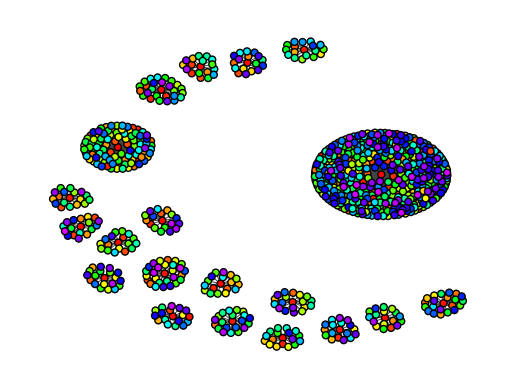

In [135]:
import matplotlib.pyplot as plt
import random

# Just grab the top 100 most connected nodes and their neighbors
# Get component sizes and sort by number of nodes
comp_sizes = [(i, len(comp)) for i, comp in enumerate(comps)]
top_comp_indices = [i for i, _ in sorted(comp_sizes, key=lambda x: x[1], reverse=True)[:20]]

# Get all nodes from these top components
top_nodes = set()
for comp_idx in top_comp_indices:
    comp_nodes = comps[comp_idx]
    top_nodes.update(comp_nodes)

# Create subgraph from these nodes
subgraph = g.subgraph(list(top_nodes))

# Plotting the top 20 most connected components
fig, ax = plt.subplots()
ig.plot(
    subgraph,
    target=ax,
    palette=ig.RainbowPalette(),
    vertex_color=list(map(int, ig.rescale(comps.membership, (0, 250)))),
    vertex_size=7,
    edge_width=0.7
)
plt.show()

Validating our Results against iGraph

In [136]:
ours_grouped = (
    assignments
    .groupby("rep")
    .agg(col("u").agg_list().alias("members"))
    .collect()
)
pdf = ours_grouped.to_pandas()
ours_comps = {frozenset(m) for m in pdf["members"]}
ig_comps = {frozenset(node_ids[i] for i in comp) for comp in comps}
if ours_comps == ig_comps:
    print(f"[VALIDATION] PASSED: components match igraph (n={len(ours_comps)})")
else:
    only_ours = ours_comps - ig_comps
    only_ig = ig_comps - ours_comps
    def _preview(sets, k=3):
        out = []
        for comp in list(sets)[:k]:
            out.append(sorted(list(int(c) for c in comp))[:10])
        return out
    print(f"[VALIDATION] MISMATCH: ours={len(ours_comps)} vs igraph={len(ig_comps)}")
    print(f"  examples only in ours: {_preview(only_ours)}")
    print(f"  examples only in igraph: {_preview(only_ig)}")

🗡️ 🐟 InMemorySource: 00:00 

🗡️ 🐟 GroupedAggregate: 00:00 

[VALIDATION] MISMATCH: ours=1048 vs igraph=1042
  examples only in ours: [[3784, 3847, 3878, 3881, 3882, 3883], [2735, 2736, 2737], [443, 446, 447, 717, 718, 719, 744, 747, 748]]
  examples only in igraph: [[3784, 3838, 3840, 3841, 3847, 3878, 3881, 3882, 3883], [443, 446, 447, 717, 718, 719, 744, 746, 747, 748], [4797, 5078, 5080, 5081, 5082, 5083]]


### Getting our results to match: Global minimum label propagation
Why this is needed:
- After alternating Large-/Small-Star and applying path compression, components can still
    stabilize with multiple local minima (distinct labels) within the same true component.
- This deterministic min-label diffusion ensures every node in a connected component adopts
    the single global minimum node-id as its representative, restoring exact parity to igraph.

**Algorithm:**
1) Symmetrize edges to build an undirected adjacency (both directions present).
2) Initialize labels(u) from assignments.rep.
3) Iterate up to lp_max_iters times:
    a) For each node, compute nbr_min(u) = min(label(v)) over neighbors v of u.
    b) Update label(u) = min(label(u), nbr_min(u)) with null-safe handling.
    c) Deduplicate and compare to prior labels; stop when the (u, label) pair set stabilizes.
4) Return labels as assignments with schema ["u", "rep"].

In [137]:
# Build an undirected view of the graph so labels can flow in both directions
E = symmetrize(b_final)

# Initialize labels from current assignments: rep becomes the working label per node
labels = assignments.select(col("u"), col("rep").alias("label")).collect()

lp_iters = 0
lp_max_iters = 100
while lp_iters < lp_max_iters:
    lp_iters += 1

    # For each node u, compute the minimum label among its neighbors
    nbr_min = (
        E
        .join(labels, left_on="v", right_on="u", how="left")
        .select(col("u").alias("node"), col("label"))
        .groupby("node")
        .agg(col("label").min().alias("nbr_min"))
        .collect()
    )

    # Lower each node's label to min(current_label, neighbor_min_label)
    labels_next = (
        labels
        .join(nbr_min, left_on="u", right_on="node", how="left")
        .with_column(
            "label",
            col("nbr_min").is_null().if_else(
                col("label"),
                (col("label") <= col("nbr_min")).if_else(col("label"), col("nbr_min")),
            ),
        )
        .select(col("u"), col("label"))
        .distinct()
        .collect()
    )

    # Convergence: compare pair sets after casting back to (u, rep)
    a = assignments.select(col("u"), col("rep").alias("label")).select(col("u"), col("label").alias("rep"))
    b = labels_next.select(col("u"), col("label").alias("rep"))
    if pairs_equal(a, b):
        break

    # Continue iterating with updated assignments/labels
    assignments = labels_next.select(col("u"), col("label").alias("rep")).collect()
    labels = labels_next

assignments_globally_reduced = assignments
clear_output()



Checking one more time

In [138]:
ours_grouped = (
    assignments_globally_reduced
    .groupby("rep")
    .agg(col("u").agg_list().alias("members"))
    .collect()
)
pdf = ours_grouped.to_pandas()
ours_comps = {frozenset(m) for m in pdf["members"]}
ig_comps = {frozenset(node_ids[i] for i in comp) for comp in comps}
if ours_comps == ig_comps:
    print(f"[VALIDATION] PASSED: components match igraph (n={len(ours_comps)})")
else:
    only_ours = ours_comps - ig_comps
    only_ig = ig_comps - ours_comps
    def _preview(sets, k=3):
        out = []
        for comp in list(sets)[:k]:
            out.append(sorted(list(int(c) for c in comp))[:10])
        return out
    print(f"[VALIDATION] MISMATCH: ours={len(ours_comps)} vs igraph={len(ig_comps)}")
    print(f"  examples only in ours: {_preview(only_ours)}")
    print(f"  examples only in igraph: {_preview(only_ig)}")

🗡️ 🐟 InMemorySource: 00:00 

🗡️ 🐟 GroupedAggregate: 00:00 

[VALIDATION] PASSED: components match igraph (n=1042)


## Merge Results


In [139]:
# First, create a mapping from node IDs to their string representations
assignments_unique = (
    assignments_globally_reduced
    .groupby("u")
    .agg(col("rep").min())
)

In [140]:
# Join the assignments with the ID mapping to get string representations
a1 = assignments_unique.join(id_map.with_column_renamed(index_col, "__u_str"), left_on="u", right_on="node_id")
a2 = a1.join(id_map.with_column_renamed(index_col, "__rep_str"), left_on="rep", right_on="node_id")
assignments_unique_str = a2.select(
    col("__u_str").alias(index_col),
    col("__rep_str").alias("component")
)

In [141]:
# Join back to original df and filter to keep only rows where the row is its own representative or isolated
df_joined = df_text.join(assignments_unique_str, on=index_col, how="left")

In [142]:
# Return the deduplicated dataset with only unique representatives
deduplicated_df = (
    df_joined
    .filter(
        col("component").is_null() | 
        (col("component") == col(index_col))
    )
    .exclude("component")
).collect()
clear_output()

In [143]:
deduplicated_df.show()

block_idUtf8,WARC-Record-IDUtf8,blockUtf8
49d8d55d-9a84-42a2-8de1-fbbf84107042-0,49d8d55d-9a84-42a2-8de1-fbbf84107042,日本福利直播軟件app
49d8d55d-9a84-42a2-8de1-fbbf84107042-1,49d8d55d-9a84-42a2-8de1-fbbf84107042,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.
49d8d55d-9a84-42a2-8de1-fbbf84107042-3,49d8d55d-9a84-42a2-8de1-fbbf84107042,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com
49d8d55d-9a84-42a2-8de1-fbbf84107042-4,49d8d55d-9a84-42a2-8de1-fbbf84107042,會員登入 加入會員 查詢密碼
49d8d55d-9a84-42a2-8de1-fbbf84107042-5,49d8d55d-9a84-42a2-8de1-fbbf84107042,會員登入
49d8d55d-9a84-42a2-8de1-fbbf84107042-6,49d8d55d-9a84-42a2-8de1-fbbf84107042,加入會員
49d8d55d-9a84-42a2-8de1-fbbf84107042-7,49d8d55d-9a84-42a2-8de1-fbbf84107042,查詢密碼
49d8d55d-9a84-42a2-8de1-fbbf84107042-8,49d8d55d-9a84-42a2-8de1-fbbf84107042,免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序


In [151]:
# Create a dataframe of the duplicates by filtering for rows that are NOT their own representative
duplicates_df = (
    df_joined
    .filter(
        col("component").not_null() & 
        (col("component") != col(index_col))
    )
    .where(
        col("block")!=" ")
    .exclude("component")
).collect()

print(f"Found {len(duplicates_df)} duplicate blocks")
print("\nSample of duplicates:")
duplicates_df.show(10)


block_idUtf8,WARC-Record-IDUtf8,blockUtf8
49d8d55d-9a84-42a2-8de1-fbbf84107042-2,49d8d55d-9a84-42a2-8de1-fbbf84107042,會員登入 加入會員 查詢密碼 客服QQ: 2094229240@qq.com 免費文字聊天區 一對一視訊聊天 / 免費一對多視訊 搜尋主持人： 業績排行 │ 分鐘數排行 │ 本站推薦 │ 本月新人 │ 一對多收費排序 │ 一對一收費排序 (七微 ) 我在休息 最近上線時間 : 2018-04-22 04:25:24 加到我的最愛 | 說明 詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市 會員總評價 相貌 平均評價 5.00 分 身材 平均評價 5.00 分 表演 平均評價 5.00 分 態度 平均評價 5.00 分 註﹕最高值 5分 會員評價 相貌 身材 表演 態度 會員[ LV4502611 ] yyyyybw 的評論： 超nice的girl，性格极好，音也好听，E杯( 2018-04-17 03:58:27 ) 相貌 身材 表演 態度 會員[ LV2185509 ] 變態叔 的評論： 正妹 一一那身材想看美女就來這裡 聽話很重要!!( 2018-04-11 01:55:11 ) 相貌 身材 表演 態度 會員[ LV3719146 ] dragon 的評論： 妹妹很投入，很配合，讓人很爽( 2018-04-04 04:23:11 ) 相貌 身材 表演 態度 會員[ LV2438679 ] good 的評論： 超棒的妹妹.配合度高很會秀.( 2018-03-23 16:32:55 ) 主持人最近30次上線記錄 項 次 日 期 進入時間 離開時間 1 2018-04-22 03:39 04:25 46 分鐘 2 01:09 03:17 128 分鐘 3 00:55 01:05 10 分鐘 4 00:00 00:53 53 分鐘 5 2018-04-21 23:56 23:59 3 分鐘 6 23:39 23:43 4 分鐘 7 23:10 23:29 19 分鐘 8 2018-04-19 02:07 02:16 9 分鐘 9 00:28 01:46 78 分鐘 10 00:00 00:05 5 分鐘 11 2018-04-18 23:40 23:59 19 分鐘 12 22:20 23:37 77 分鐘 13 21:52 22:18 26 分鐘 14 03:27 03:38 11 分鐘 15 01:19 03:24 125 分鐘 16 00:40 01:00 20 分鐘 17 00:11 00:22 11 分鐘 18 2018-04-17 23:40 23:52 12 分鐘 19 23:15 23:30 15 分鐘 20 23:10 23:13 3 分鐘 21 13:27 13:45 19 分鐘 22 12:49 13:24 35 分鐘 23 12:15 12:40 24 分鐘 24 02:32 04:21 109 分鐘 25 00:45 02:08 84 分鐘 26 00:00 00:37 38 分鐘 27 2018-04-16 23:19 23:59 40 分鐘 28 21:12 22:57 105 分鐘 29 15:44 16:16 32 分鐘 30 12:10 14:36 146 分鐘 主持人個人首頁 | 評價 | 記錄 COPYRIGHT(C)2006 1765634.yyappyy.com ALL RIGHTS RESERVED.
49d8d55d-9a84-42a2-8de1-fbbf84107042-19,49d8d55d-9a84-42a2-8de1-fbbf84107042,詳細資料 免費文字聊天: 必需付費才可聊天 血型: 一對多視訊聊天: 每分鐘 8 點 身高: 公分(cm) 一對一視訊聊天: 每分鐘 30 點 體重: 公斤(kg) 性別: 女性 三圍: 年齡: 19 歲 區域: 苗栗縣市
49d8d55d-9a84-42a2-8de1-fbbf84107042-35,49d8d55d-9a84-42a2-8de1-fbbf84107042,平均評價 5.00 分
49d8d55d-9a84-42a2-8de1-fbbf84107042-37,49d8d55d-9a84-42a2-8de1-fbbf84107042,平均評價 5.00 分
49d8d55d-9a84-42a2-8de1-fbbf84107042-39,49d8d55d-9a84-42a2-8de1-fbbf84107042,平均評價 5.00 分
49d8d55d-9a84-42a2-8de1-fbbf84107042-42,49d8d55d-9a84-42a2-8de1-fbbf84107042,相貌
49d8d55d-9a84-42a2-8de1-fbbf84107042-43,49d8d55d-9a84-42a2-8de1-fbbf84107042,身材
49d8d55d-9a84-42a2-8de1-fbbf84107042-44,49d8d55d-9a84-42a2-8de1-fbbf84107042,表演
49d8d55d-9a84-42a2-8de1-fbbf84107042-45,49d8d55d-9a84-42a2-8de1-fbbf84107042,態度
49d8d55d-9a84-42a2-8de1-fbbf84107042-47,49d8d55d-9a84-42a2-8de1-fbbf84107042,相貌


## Conclusion

In this notebook, we built an end‑to‑end, scalable deduplication pipeline for web text:

- Ingested WARC from Common Crawl (S3) and extracted meaningful HTML blocks
- Normalized text to a consistent, noise‑reduced representation
- Computed MinHash signatures (K, ngram_size, seed) and bucketed with LSH (optimal B, R)
- Collapsed buckets into a graph and found connected components via alternating Large‑/Small‑Star
- Verified components against igraph and applied global minimum label propagation for a single representative per component
- Produced both a deduplicated dataset and a duplicates table for inspection

Why this is helpful/important
- Reduces memorization and regurgitation in LLMs, improving generalization and safety
- Eliminates redundant tokens to lower training cost and sharpen downstream evaluations
- Transparent, parameterized method that scales with Daft and S3; easy to tune and reproduce

Where to take it next
- Your use case will most likely specializes in a specific domain or area of expertise so filter content for whats most relevent to you. 
- Experiment with Tuning K and the LSH similarity threshold to balance recall vs precision at your scale
- Persist intermediate artifacts (minhashes, bands, edges) to accelerate iterations
- Add domain/language filters and stronger boilerplate removal before hashing
- Operationalize as a scheduled job over new Common Crawl snapshots
- Integrate additional quality signals (toxicity, heuristics) pre‑/post‑dedup

Outputs to expect
- A deduplicated view (`deduplicated_df`) ready for downstream training
- A `duplicates_df` sample to spot‑check clusters and validate quality